# 05. Обучение модели вероятности продажи

- **Единица:** rolling-snapshot — в риск-сет входят ВСЕ месячные срезы лота (не только последний) → задача `P(лот продастся в течение месяца, 30 дней)`.
- **Таргет:** `is_sold_next_month` (30-дневный горизонт).
- **Риск-сет:** исключены `is_sold_past` (лот зарегистрирован ранее) и правоцензурированные срезы (`file_date > 2025-04-30` — нет полного 30-дневного окна до края данных). Вес лота `1/√(n снапшотов)`, чтобы длинные истории не доминировали.
- **Сплит по времени (purge-gap = горизонт, 30д):** train < 2024-05 · val 2024-06…08 · test 2024-10…2025-04-30. Зазоры по 1 мес (= горизонт) — минимальные, окна таргета не пересекаются.
- **Модель:** CatBoost (`auto_class_weights=Balanced`) + изотоническая калибровка вероятностей.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import joblib
from catboost import CatBoostClassifier, Pool
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             log_loss, precision_recall_curve)
from sklearn.calibration import calibration_curve

_cwd = Path.cwd().resolve()
REPO_ROOT = _cwd if (_cwd / "data").is_dir() else _cwd.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from src.config import MODEL_DATASET_PARQUET, MODELS_DIR, MODEL_PATH

C1, C2 = "#2C7BB6", "#D7542B"
plt.rcParams.update({"figure.dpi": 130, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.right": False, "axes.spines.top": False})
FIG_DIR = REPO_ROOT / "reports" / "figures" / "05_training"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "is_sold_next_month"

# --- ГРУППЫ ФИЧ ---
# BASE: лот / цена / динамика цены / жизненный цикл / макро (рыночных тут нет)
BASE_NUM = [
    "area", "floor",
    "price", "log_price", "price_no_discount", "discount_pct", "discount_abs",
    "price_change_pct_1", "price_change_from_first", "discount_change_1", "days_since_prev", "n_price_changes",
    "exposure", "row_number", "days_since_sales_start", "months_to_completion", "file_month", "file_year",
    "history_truncated", "key_rate", "inflation", "real_rate",
]
# MARKET: единый скоуп «текущий рынок + динамика» (после дедупликации убран price_z_seg)
MARKET = [
    # позиция/уровень/разброс цены в сегменте (file_date x district x class x room)
    "rel_price", "seg_median_price", "price_rank_seg", "seg_count",
    "seg_price_iqr", "seg_price_cv", "price_gap_to_p10",
    # предложение и конкуренция
    "n_active_project", "n_active_building", "n_active_district", "competitor_density", "room_share_project",
    # динамика предложения и уровня цен
    "seg_count_chg_1m", "seg_count_chg_3m", "seg_median_price_chg_1m", "seg_median_price_chg_3m",
    "seg_median_price_chg_6m", "share_new_supply",
    # спрос / absorption
    "seg_sold_prev_3m", "seg_absorption_3m", "months_of_inventory",
    # возраст / застой предложения
    "seg_median_exposure", "rel_exposure", "seg_median_age", "share_stale_seg",
    # макро-моментум
    "key_rate_chg_3m", "key_rate_chg_6m", "real_rate_chg_3m", "inflation_chg_3m",
    # вложенные бенчмарки
    "rel_price_district", "seg_premium", "dev_price_premium",
]

CAT_FEATURES = [
    "project_class", "project_name", "region", "macro_district", "district", "room_count", "premises_type",
    "finish_tier", "finish_in_report", "unit_typology", "stage_k", "contract_type_k", "developer",
]
print(f"BASE_NUM={len(BASE_NUM)}  MARKET={len(MARKET)}  CAT={len(CAT_FEATURES)}")
# GEO_FEATURES определяется после загрузки датасета (детект по остаточным колонкам)

BASE_NUM=22  MARKET=32  CAT=13


## 1. Риск-сет: последний срез лота + фильтры

In [2]:
df = pd.read_parquet(MODEL_DATASET_PARQUET)

# right-censoring: честно размечаются только срезы с полным 30-дневным окном.
HORIZON_CUT = pd.Timestamp("2025-04-30")
data = df[(df["is_sold_past"] == 0) & (df["file_date"] <= HORIZON_CUT)].copy()

# вес по лоту: длинные истории не доминируют (1/sqrt(n снапшотов в риск-сете)).
n_snap = data.groupby("unit_match_key")["file_date"].transform("size")
data["row_weight"] = 1.0 / np.sqrt(n_snap)

n_post = int((df["is_sold_past"] == 1).sum())
n_cens = int((df["file_date"] > HORIZON_CUT).sum())
print(f"строк: {len(df):,} → риск-сет: {len(data):,}  (−post-sale {n_post:,}, −censored {n_cens:,})")
print(f"лотов: {data['unit_match_key'].nunique():,}  |  pos-rate {TARGET}: {100*data[TARGET].mean():.2f}%")
print(f"file_date: {data['file_date'].min().date()} … {data['file_date'].max().date()}")

# GEO_FEATURES = всё, что есть в датасете, но не вошло в BASE/MARKET/CAT/таргеты
_TARGETS = ["is_sold", "is_sold_next_month", "is_sold_next_quarter", "is_sold_past", "unit_status"]
_KNOWN = set(["unit_match_key", "file_date", "row_weight"] + BASE_NUM + MARKET + CAT_FEATURES + _TARGETS)
GEO_FEATURES = [c for c in df.columns if c not in _KNOWN]
print(f"GEO_FEATURES (остаточные колонки): {len(GEO_FEATURES)} -> {GEO_FEATURES}")

строк: 4,631,451 → риск-сет: 4,496,760  (−post-sale 30,343, −censored 105,057)
лотов: 865,453  |  pos-rate is_sold_next_month: 1.70%
file_date: 2021-02-01 … 2025-04-02
GEO_FEATURES (остаточные колонки): 35 -> ['dist_to_metro_m', 'dist_to_school_m', 'dist_to_water_m', 'dist_to_industrial_m', 'dist_to_cemetery_m', 'dist_to_power_line_m', 'dist_to_major_road_m', 'dist_to_railway_m', 'schools_count_500m', 'schools_count_1000m', 'schools_count_2000m', 'green_share_500m', 'green_share_1000m', 'green_share_2000m', 'water_share_500m', 'water_share_1000m', 'water_share_2000m', 'industrial_share_500m', 'industrial_share_1000m', 'industrial_share_2000m', 'cemetery_share_500m', 'cemetery_share_1000m', 'cemetery_share_2000m', 'major_roads_length_500m', 'major_roads_length_1000m', 'major_roads_length_2000m', 'railway_length_500m', 'railway_length_1000m', 'railway_length_2000m', 'power_lines_length_500m', 'power_lines_length_1000m', 'power_lines_length_2000m', 'nearby_complexes_count_500m', 'nearby_c

## 2. Временной сплит

In [3]:
# временной сплит с purge-gap = горизонт (30д). Сплит по file_date — одинаков для всех блоков.
TRAIN_END          = "2024-05-01"
VAL_FROM, VAL_TO   = "2024-06-01", "2024-09-01"
TEST_FROM          = "2024-10-01"

train = data[data["file_date"] < TRAIN_END]
val   = data[(data["file_date"] >= VAL_FROM) & (data["file_date"] < VAL_TO)]
test  = data[data["file_date"] >= TEST_FROM]

for nm, x in [("train", train), ("val", val), ("test", test)]:
    print(f"{nm:5s} {len(x):>9,}  pos={100*x[TARGET].mean():4.2f}%  "
          f"лотов={x['unit_match_key'].nunique():>7,}  ({x.file_date.min().date()} … {x.file_date.max().date()})")

def make_xy(part, feats):
    X = part[feats].copy()
    for c in CAT_FEATURES:
        if c in X.columns:
            X[c] = X[c].fillna("__NA__").astype(str)   # CatBoost: категориальные без NaN
    return X, part[TARGET].astype(int), part["row_weight"].to_numpy()

train 3,231,807  pos=1.68%  лотов=678,398  (2021-02-01 … 2024-04-02)
val     313,173  pos=1.61%  лотов=145,538  (2024-06-03 … 2024-08-02)
test    737,220  pos=1.73%  лотов=209,904  (2024-10-02 … 2025-04-02)


## Блок 1 — без рыночных и гео фич (baseline)
Метрики на test (сырые скоры) + feature importance.

0:	learn: 0.7071658	test: 0.6269842	best: 0.6269842 (0)	total: 1.4s	remaining: 23m 22s
100:	learn: 0.8285769	test: 0.7139590	best: 0.7145766 (97)	total: 2m	remaining: 17m 52s
200:	learn: 0.8415598	test: 0.7157086	best: 0.7174910 (194)	total: 4m 9s	remaining: 16m 29s
300:	learn: 0.8501847	test: 0.7220090	best: 0.7220090 (300)	total: 6m 17s	remaining: 14m 37s
400:	learn: 0.8563663	test: 0.7249258	best: 0.7253768 (381)	total: 8m 23s	remaining: 12m 31s
500:	learn: 0.8611372	test: 0.7272585	best: 0.7281761 (478)	total: 10m 29s	remaining: 10m 27s
600:	learn: 0.8648654	test: 0.7305347	best: 0.7305347 (600)	total: 12m 36s	remaining: 8m 22s
700:	learn: 0.8681206	test: 0.7319283	best: 0.7322780 (688)	total: 14m 41s	remaining: 6m 15s
800:	learn: 0.8710742	test: 0.7328887	best: 0.7328887 (800)	total: 16m 46s	remaining: 4m 10s
900:	learn: 0.8736300	test: 0.7343732	best: 0.7343732 (900)	total: 18m 55s	remaining: 2m 4s
999:	learn: 0.8758820	test: 0.7353048	best: 0.7353239 (998)	total: 21m 1s	remainin

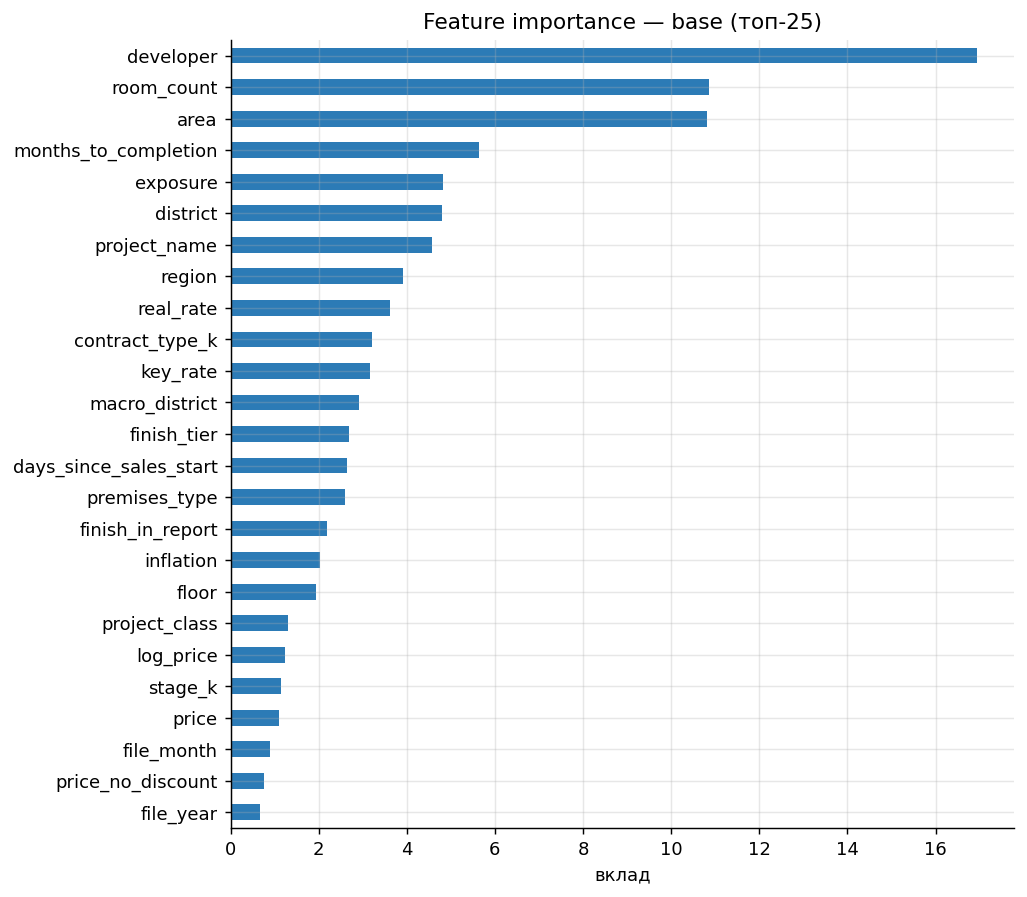

In [4]:
feats = BASE_NUM + CAT_FEATURES
X_train, y_train, w_train = make_xy(train, feats)
X_val,   y_val,   w_val   = make_xy(val,   feats)
X_test,  y_test,  w_test  = make_xy(test,  feats)

m1 = CatBoostClassifier(
        iterations=1000, learning_rate=0.05, depth=6,
        loss_function="Logloss", eval_metric="PRAUC",
        auto_class_weights="Balanced", random_seed=42,
        early_stopping_rounds=100, verbose=100,
    )
m1.fit(Pool(X_train, y_train, cat_features=CAT_FEATURES, weight=w_train),
       eval_set=Pool(X_val, y_val, cat_features=CAT_FEATURES, weight=w_val))
print("итераций:", m1.tree_count_)

# метрики на test (без калибровки)
p1 = m1.predict_proba(X_test)[:, 1]
base = y_test.mean()
pr1 = average_precision_score(y_test, p1)
print(f"ROC-AUC {roc_auc_score(y_test, p1):.4f} | PR-AUC {pr1:.4f} "
      f"(baseline {base:.4f}, lift x{pr1/base:.1f}) | "
      f"Brier {brier_score_loss(y_test, p1):.4f} | LogLoss {log_loss(y_test, p1):.4f}")

fi1 = pd.Series(m1.get_feature_importance(), index=feats).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 7)); fi1.head(25)[::-1].plot.barh(ax=ax, color=C1); ax.set_xlabel("вклад")
fig.tight_layout(); fig.savefig(FIG_DIR / "fi_1_base.png", bbox_inches="tight"); plt.show()

res1 = dict(label="1 · base", n_feats=len(feats), iters=int(m1.tree_count_),
            roc_auc=roc_auc_score(y_test, p1), pr_auc=pr1, lift=pr1/base,
            brier=brier_score_loss(y_test, p1), logloss=log_loss(y_test, p1),
            model=m1, feats=feats, p_test=p1)

## Блок 2 — + рыночные фичи (MARKET)
То же + сравнение с блоком 1.

0:	learn: 0.7579754	test: 0.6925189	best: 0.6925189 (0)	total: 1.45s	remaining: 24m 10s
100:	learn: 0.8348611	test: 0.7528607	best: 0.7533536 (99)	total: 2m 7s	remaining: 18m 52s
200:	learn: 0.8478145	test: 0.7551010	best: 0.7569097 (148)	total: 4m 21s	remaining: 17m 19s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7569096853
bestIteration = 148

Shrink model to first 149 iterations.
итераций: 149
ROC-AUC 0.8271 | PR-AUC 0.0906 (baseline 0.0173, lift x5.2) | Brier 0.1524 | LogLoss 0.4521

Δ vs base:  PR-AUC 0.0595→0.0906 (+0.0311) | ROC 0.7929→0.8271 (+0.0342) | Brier 0.1625→0.1524 | LogLoss 0.4728→0.4521


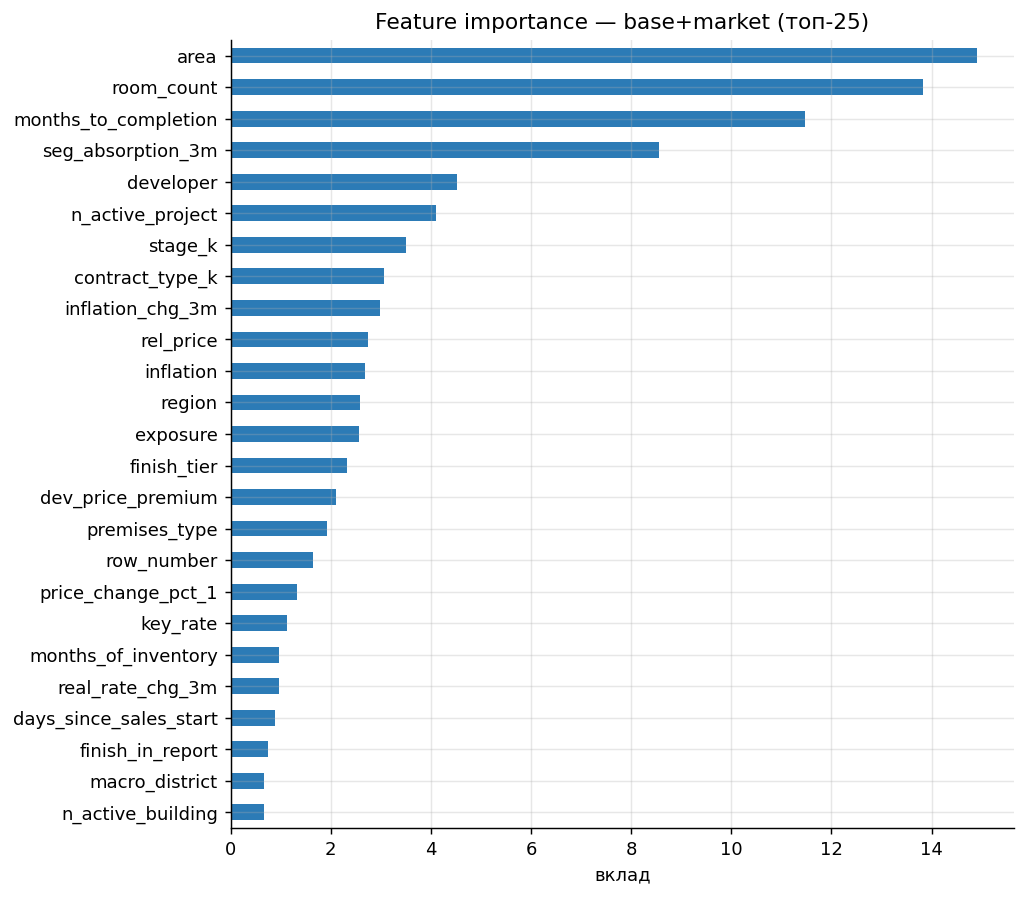

суммарная важность рыночных фич: 25.5%
топ-10 рыночных:
seg_absorption_3m      8.56
n_active_project       4.11
inflation_chg_3m       2.99
rel_price              2.74
dev_price_premium      2.10
months_of_inventory    0.97
real_rate_chg_3m       0.97
n_active_building      0.67
rel_exposure           0.44
share_new_supply       0.33


In [5]:
feats = BASE_NUM + MARKET + CAT_FEATURES
X_train, y_train, w_train = make_xy(train, feats)
X_val,   y_val,   w_val   = make_xy(val,   feats)
X_test,  y_test,  w_test  = make_xy(test,  feats)

m2 = CatBoostClassifier(
        iterations=1000, learning_rate=0.05, depth=6,
        loss_function="Logloss", eval_metric="PRAUC",
        auto_class_weights="Balanced", random_seed=42,
        early_stopping_rounds=100, verbose=100,
    )
m2.fit(Pool(X_train, y_train, cat_features=CAT_FEATURES, weight=w_train),
       eval_set=Pool(X_val, y_val, cat_features=CAT_FEATURES, weight=w_val))
print("итераций:", m2.tree_count_)

p2 = m2.predict_proba(X_test)[:, 1]
base = y_test.mean()
pr2 = average_precision_score(y_test, p2)
print(f"ROC-AUC {roc_auc_score(y_test, p2):.4f} | PR-AUC {pr2:.4f} "
      f"(baseline {base:.4f}, lift x{pr2/base:.1f}) | "
      f"Brier {brier_score_loss(y_test, p2):.4f} | LogLoss {log_loss(y_test, p2):.4f}")

# сравнение с блоком 1
print(f"\nΔ vs base:  "
      f"PR-AUC {res1['pr_auc']:.4f}→{pr2:.4f} ({pr2-res1['pr_auc']:+.4f}) | "
      f"ROC {res1['roc_auc']:.4f}→{roc_auc_score(y_test, p2):.4f} ({roc_auc_score(y_test, p2)-res1['roc_auc']:+.4f}) | "
      f"Brier {res1['brier']:.4f}→{brier_score_loss(y_test, p2):.4f} | "
      f"LogLoss {res1['logloss']:.4f}→{log_loss(y_test, p2):.4f}")

fi2 = pd.Series(m2.get_feature_importance(), index=feats).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 7)); fi2.head(25)[::-1].plot.barh(ax=ax, color=C1); ax.set_xlabel("вклад")
fig.tight_layout(); fig.savefig(FIG_DIR / "fi_2_market.png", bbox_inches="tight"); plt.show()

mkt_share = 100 * fi2.reindex(MARKET).fillna(0).sum() / fi2.sum()
print(f"суммарная важность рыночных фич: {mkt_share:.1f}%")
print("топ-10 рыночных:")
print(fi2.reindex(MARKET).dropna().sort_values(ascending=False).head(10).round(2).to_string())

res2 = dict(label="2 · base+market", n_feats=len(feats), iters=int(m2.tree_count_),
            roc_auc=roc_auc_score(y_test, p2), pr_auc=pr2, lift=pr2/base,
            brier=brier_score_loss(y_test, p2), logloss=log_loss(y_test, p2),
            model=m2, feats=feats, p_test=p2)

## Блок 3 — + геофичи (поверх base+market)
То же + сравнение с блоком 2. Если гео отключены — блок пропускается.

0:	learn: 0.7509605	test: 0.6989652	best: 0.6989652 (0)	total: 1.56s	remaining: 25m 58s
100:	learn: 0.8369130	test: 0.7587355	best: 0.7587355 (100)	total: 2m 13s	remaining: 19m 45s
200:	learn: 0.8508482	test: 0.7704838	best: 0.7704838 (200)	total: 5m 37s	remaining: 22m 21s
300:	learn: 0.8596189	test: 0.7736003	best: 0.7736003 (300)	total: 9m 41s	remaining: 22m 31s
400:	learn: 0.8663539	test: 0.7783995	best: 0.7783995 (400)	total: 13m 57s	remaining: 20m 50s
500:	learn: 0.8716537	test: 0.7825585	best: 0.7826143 (495)	total: 17m 22s	remaining: 17m 17s
600:	learn: 0.8759193	test: 0.7853486	best: 0.7853486 (600)	total: 19m 53s	remaining: 13m 12s
700:	learn: 0.8794861	test: 0.7868119	best: 0.7868797 (661)	total: 22m 33s	remaining: 9m 37s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7868796797
bestIteration = 661

Shrink model to first 662 iterations.
итераций: 662
ROC-AUC 0.8424 | PR-AUC 0.0916 (baseline 0.0173, lift x5.3) | Brier 0.1294 | LogLoss 0.3854

Δ vs base+ma

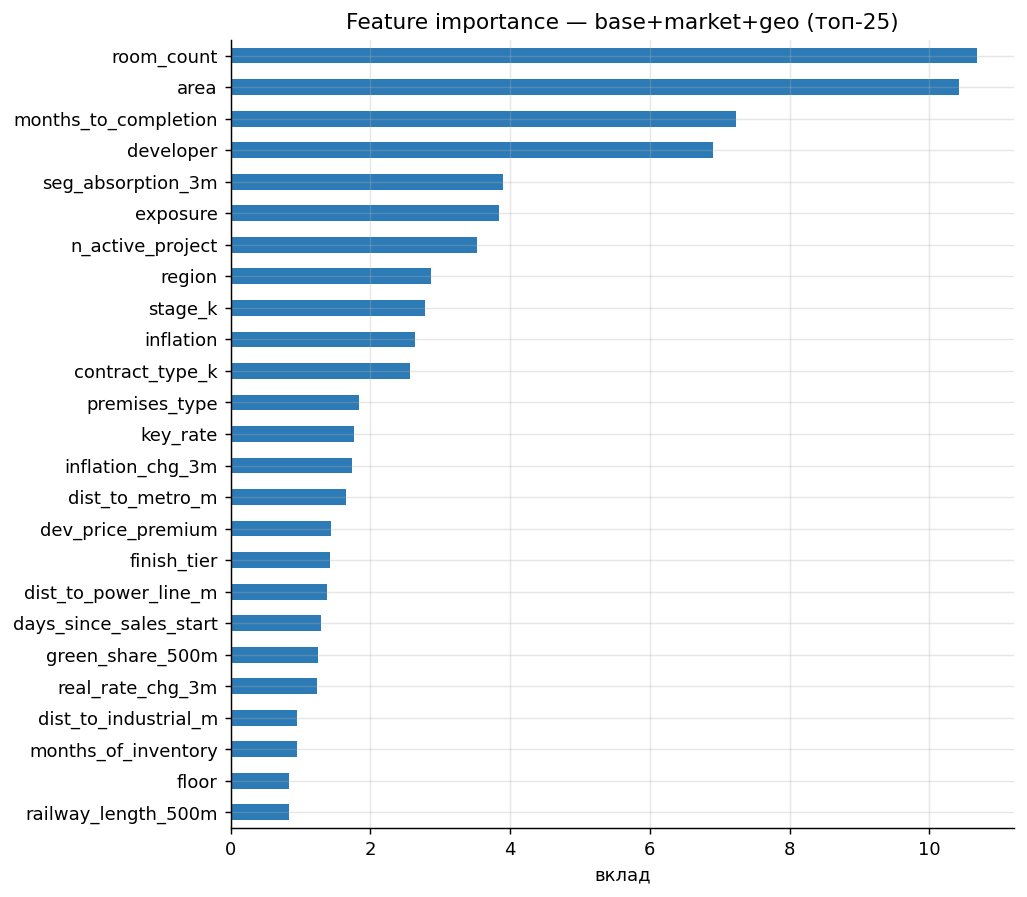

суммарная важность геофич: 19.3%


In [6]:
feats = BASE_NUM + MARKET + GEO_FEATURES + CAT_FEATURES
X_train, y_train, w_train = make_xy(train, feats)
X_val,   y_val,   w_val   = make_xy(val,   feats)
X_test,  y_test,  w_test  = make_xy(test,  feats)

m3 = CatBoostClassifier(
    iterations=1000, learning_rate=0.05, depth=6,
    loss_function="Logloss", eval_metric="PRAUC",
    auto_class_weights="Balanced", random_seed=42,
    early_stopping_rounds=100, verbose=100,
)
m3.fit(Pool(X_train, y_train, cat_features=CAT_FEATURES, weight=w_train),
       eval_set=Pool(X_val, y_val, cat_features=CAT_FEATURES, weight=w_val))
print("итераций:", m3.tree_count_)

p3 = m3.predict_proba(X_test)[:, 1]
base = y_test.mean()
pr3 = average_precision_score(y_test, p3)
print(f"ROC-AUC {roc_auc_score(y_test, p3):.4f} | PR-AUC {pr3:.4f} "
      f"(baseline {base:.4f}, lift x{pr3/base:.1f}) | "
      f"Brier {brier_score_loss(y_test, p3):.4f} | LogLoss {log_loss(y_test, p3):.4f}")
print(f"\nΔ vs base+market:  "
      f"PR-AUC {res2['pr_auc']:.4f}→{pr3:.4f} ({pr3-res2['pr_auc']:+.4f}) | "
      f"ROC {res2['roc_auc']:.4f}→{roc_auc_score(y_test, p3):.4f} | "
      f"Brier {res2['brier']:.4f}→{brier_score_loss(y_test, p3):.4f} | "
      f"LogLoss {res2['logloss']:.4f}→{log_loss(y_test, p3):.4f}")

fi3 = pd.Series(m3.get_feature_importance(), index=feats).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 7)); fi3.head(25)[::-1].plot.barh(ax=ax, color=C1); ax.set_xlabel("вклад")
fig.tight_layout(); fig.savefig(FIG_DIR / "fi_3_geo.png", bbox_inches="tight"); plt.show()

geo_share = 100 * fi3.reindex(GEO_FEATURES).fillna(0).sum() / fi3.sum()
print(f"суммарная важность геофич: {geo_share:.1f}%")
res3 = dict(label="3 · base+market+geo", n_feats=len(feats), iters=int(m3.tree_count_),
            roc_auc=roc_auc_score(y_test, p3), pr_auc=pr3, lift=pr3/base,
            brier=brier_score_loss(y_test, p3), logloss=log_loss(y_test, p3),
            model=m3, feats=feats, p_test=p3)

## Сравнение блоков

In [7]:
results = [res1, res2] + ([res3] if res3 else [])
cols = ["n_feats", "iters", "roc_auc", "pr_auc", "lift", "brier", "logloss"]
summary = pd.DataFrame([{k: r[k] for k in ["label"] + cols} for r in results]).set_index("label")
display(summary.round(4))

,n_feats,iters,roc_auc,pr_auc,lift,brier,logloss
label,,,,,,,
1 · base,35,999,0.7929,0.0595,3.4325,0.1625,0.4728
2 · base+market,67,149,0.8271,0.0906,5.2292,0.1524,0.4521
3 · base+market+geo,102,662,0.8424,0.0916,5.2850,0.1294,0.3854


## Блок 4 — калибровка финальной модели + сохранение
Финальная модель `base+market+geo` (блок 3) → изотоническая калибровка на val → сохранение (`.cbm` + `CalibratedModel`).

Финальная модель: 3 · base+market+geo  (PR-AUC 0.0916, фич 102)
                     Brier    LogLoss
  до калибровки:    0.1294   0.3854
  после калибровки: 0.0164   0.0756
  (ранжирование/ROC-AUC изотоника не меняет)


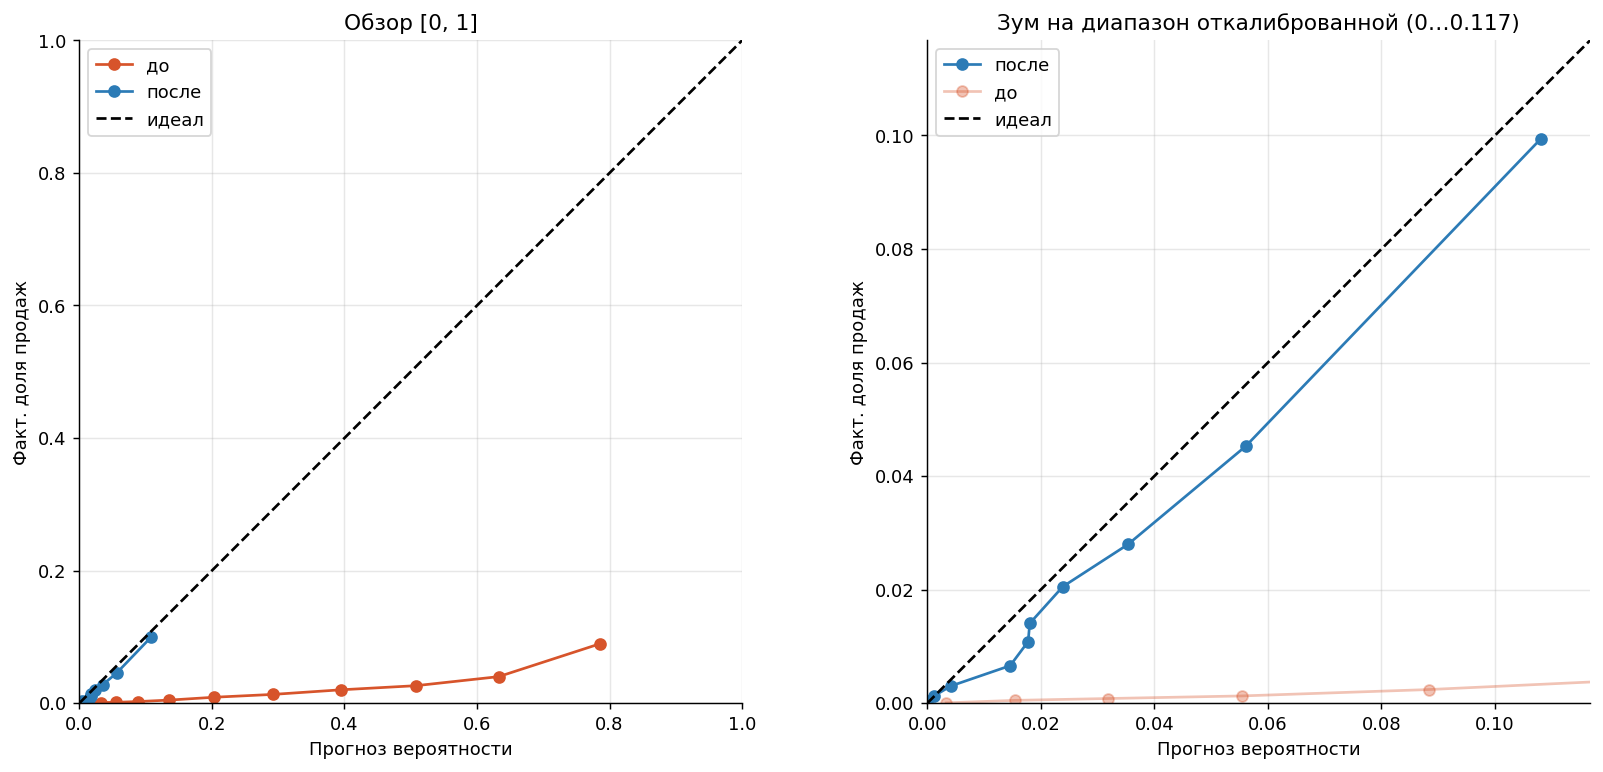


Сохранено: catboost_sale_prob.cbm + catboost_sale_prob_calibrated.pkl  | фич: 102


In [12]:
# Финальная модель — base+market+geo (блок 3) с дефолтными параметрами (без CV/тюнинга).
geo_models = [r for r in results if "geo" in r["label"] and not r["label"].startswith("tuned")]
best = geo_models[0] if geo_models else max(results, key=lambda r: r["pr_auc"])
print(f"Финальная модель: {best['label']}  (PR-AUC {best['pr_auc']:.4f}, фич {best['n_feats']})")

model = best["model"]; feats = best["feats"]
X_val,  y_val,  w_val  = make_xy(val,  feats)
X_test, y_test, w_test = make_xy(test, feats)
p_val  = model.predict_proba(X_val)[:, 1]
p_test = best["p_test"]

iso = IsotonicRegression(out_of_bounds="clip").fit(p_val, y_val, sample_weight=w_val)
p_test_cal = np.clip(iso.predict(p_test), 0, 1)

print("                     Brier    LogLoss")
print(f"  до калибровки:    {brier_score_loss(y_test, p_test):.4f}   {log_loss(y_test, p_test):.4f}")
print(f"  после калибровки: {brier_score_loss(y_test, p_test_cal):.4f}   {log_loss(y_test, p_test_cal):.4f}")
print("  (ранжирование/ROC-AUC изотоника не меняет)")

# prob_true (факт. доля), prob_pred (средний прогноз) по квантильным бинам
ft_raw, fp_raw = calibration_curve(y_test, p_test,     n_bins=12, strategy="quantile")
ft_cal, fp_cal = calibration_curve(y_test, p_test_cal, n_bins=12, strategy="quantile")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# (1) обзор на [0,1]: видно, что сырые скоры (balanced) сильно завышены
ax = axes[0]
ax.plot(fp_raw, ft_raw, "o-", color=C2, label="до")
ax.plot(fp_cal, ft_cal, "o-", color=C1, label="после")
ax.plot([0, 1], [0, 1], "--k", label="идеал")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal", "box")
ax.set_xlabel("Прогноз вероятности"); ax.set_ylabel("Факт. доля продаж")
ax.set_title("Обзор [0, 1]"); ax.legend(loc="upper left")

# (2) зум на рабочий диапазон откалиброванной модели (base-rate ~1.7%)
hi = float(max(fp_cal.max(), ft_cal.max())) * 1.08
ax = axes[1]
ax.plot(fp_cal, ft_cal, "o-", color=C1, label="после")
ax.plot(fp_raw, ft_raw, "o-", color=C2, alpha=0.35, label="до")
ax.plot([0, hi], [0, hi], "--k", label="идеал")
ax.set_xlim(0, hi); ax.set_ylim(0, hi); ax.set_aspect("equal", "box")
ax.grid(True, which="both", alpha=0.3)
ax.set_xlabel("Прогноз вероятности"); ax.set_ylabel("Факт. доля продаж")
ax.set_title(f"Зум на диапазон откалиброванной (0…{hi:.3f})"); ax.legend(loc="upper left")

fig.tight_layout(); fig.savefig(FIG_DIR / "calibration_best.png", bbox_inches="tight"); plt.show()

from src.modeling import CalibratedModel
MODELS_DIR.mkdir(parents=True, exist_ok=True)
model.save_model(str(MODEL_PATH))
cal = CalibratedModel(model, iso, feats, CAT_FEATURES)
joblib.dump(cal, MODELS_DIR / "catboost_sale_prob_calibrated.pkl")
print(f"\nСохранено: {MODEL_PATH.name} + catboost_sale_prob_calibrated.pkl  | фич: {len(feats)}")

## Блок 5 — интерпретируемость: важность по группам и SHAP
Интерпретируемость финальной модели `base+market+geo`: важность по группам (5.1) и SHAP-направления (5.2). Инференс, без переобучения.

Важность по группам, %:
base      28.4
market    22.8
geo       27.3
cat       21.5

Топ-15 признаков:
months_to_completion      11.90
developer                  6.69
seg_absorption_3m          6.62
area                       5.25
room_count                 4.08
n_active_project           2.99
region                     2.87
real_rate_chg_3m           2.75
dist_to_power_line_m       2.28
dist_to_metro_m            2.19
file_month                 2.14
contract_type_k            1.95
exposure                   1.95
days_since_sales_start     1.87
green_share_500m           1.76


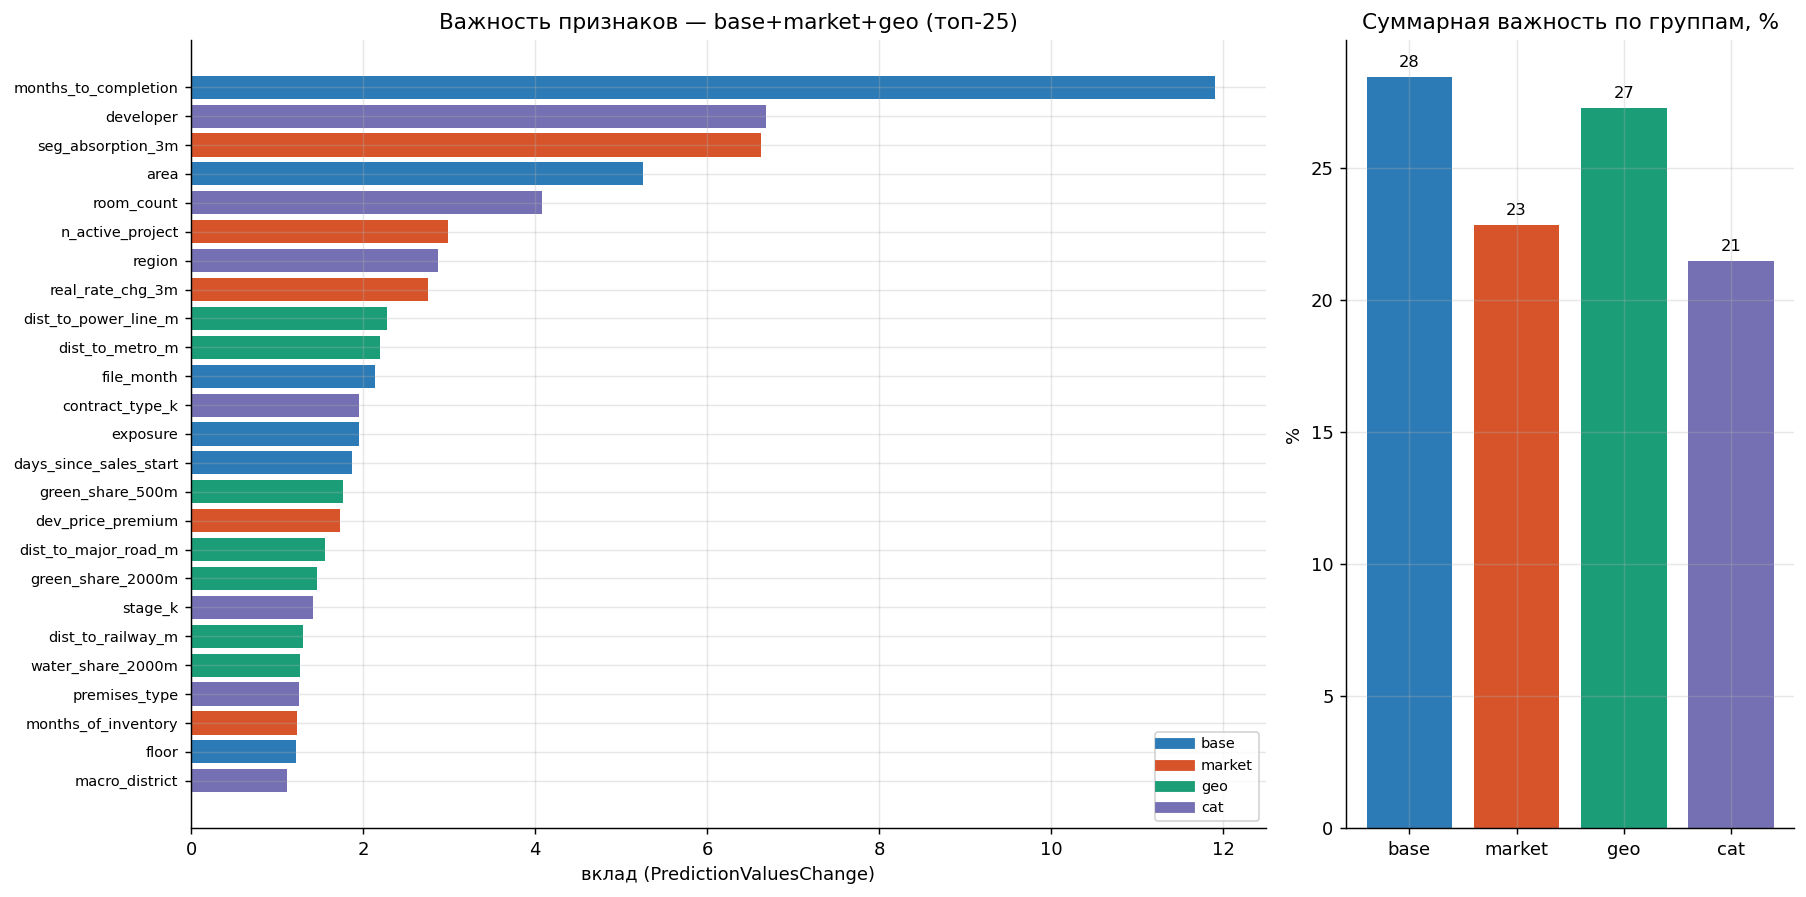

In [13]:
# Блок 5.1 — важность признаков с группировкой по блокам (на финальной модели base+market+geo)
from matplotlib.lines import Line2D

def _grp(f):
    if f in CAT_FEATURES: return "cat"
    if f in BASE_NUM:     return "base"
    if f in MARKET:       return "market"
    return "geo"   # остаточные числовые = гео
GRP_COLOR = {"base": "#2C7BB6", "market": "#D7542B", "geo": "#1B9E77", "cat": "#7570B3"}

X_test, y_test, _ = make_xy(test, feats)   # feats/model — финальная модель base+market+geo из блока 4
imp = pd.Series(model.get_feature_importance(Pool(X_test, y_test, cat_features=CAT_FEATURES)),
                index=feats).sort_values(ascending=False)
grp_tot = imp.groupby(pd.Series({f: _grp(f) for f in feats})).sum().reindex(["base", "market", "geo", "cat"])
print("Важность по группам, %:")
print((100 * grp_tot / imp.sum()).round(1).to_string())
print("\nТоп-15 признаков:")
print(imp.head(15).round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 7), gridspec_kw={"width_ratios": [2.4, 1]})
top = imp.head(25)[::-1]
axes[0].barh(range(len(top)), top.values, color=[GRP_COLOR[_grp(f)] for f in top.index])
axes[0].set_yticks(range(len(top))); axes[0].set_yticklabels(top.index, fontsize=8)
axes[0].set_title("Важность признаков — base+market+geo (топ-25)")
axes[0].set_xlabel("вклад (PredictionValuesChange)")
axes[0].legend(handles=[Line2D([0], [0], color=c, lw=6, label=g) for g, c in GRP_COLOR.items()],
               fontsize=8, loc="lower right")
gt = 100 * grp_tot / imp.sum()
axes[1].bar(range(len(gt)), gt.values, color=[GRP_COLOR[g] for g in gt.index])
axes[1].set_xticks(range(len(gt))); axes[1].set_xticklabels(gt.index)
axes[1].set_title("Суммарная важность по группам, %"); axes[1].set_ylabel("%")
for i, v in enumerate(gt.values): axes[1].text(i, v + 0.4, f"{v:.0f}", ha="center", fontsize=9)
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_feature_importance_groups.png", bbox_inches="tight"); plt.show()

### 5.2 SHAP — направление влияния признаков
SHAP (нативные, CatBoost) на выборке теста: знак вклада = направление влияния на P(продажа за 30 дней); для числовых — через corr(значение, SHAP).

SHAP base value (логит) = -1.995

признак                       группа   mean|shap|   corr  направление
months_to_completion          base         0.4877   0.57  ↑ → выше P
room_count                    cat          0.4807     --  категориальный (знак не определён)
seg_absorption_3m             market       0.4438   0.77  ↑ → выше P
area                          base         0.2791   0.23  ↑ → выше P
developer                     cat          0.2341     --  категориальный (знак не определён)
n_active_project              market       0.1713  -0.92  ↑ → ниже P
floor                         base         0.1662  -0.49  ↑ → ниже P
dev_price_premium             market       0.1647   0.83  ↑ → выше P
region                        cat          0.1636     --  категориальный (знак не определён)
stage_k                       cat          0.1437     --  категориальный (знак не определён)
key_rate                      base         0.1388    nan  ≈0
contract_type_k               cat          0.1279

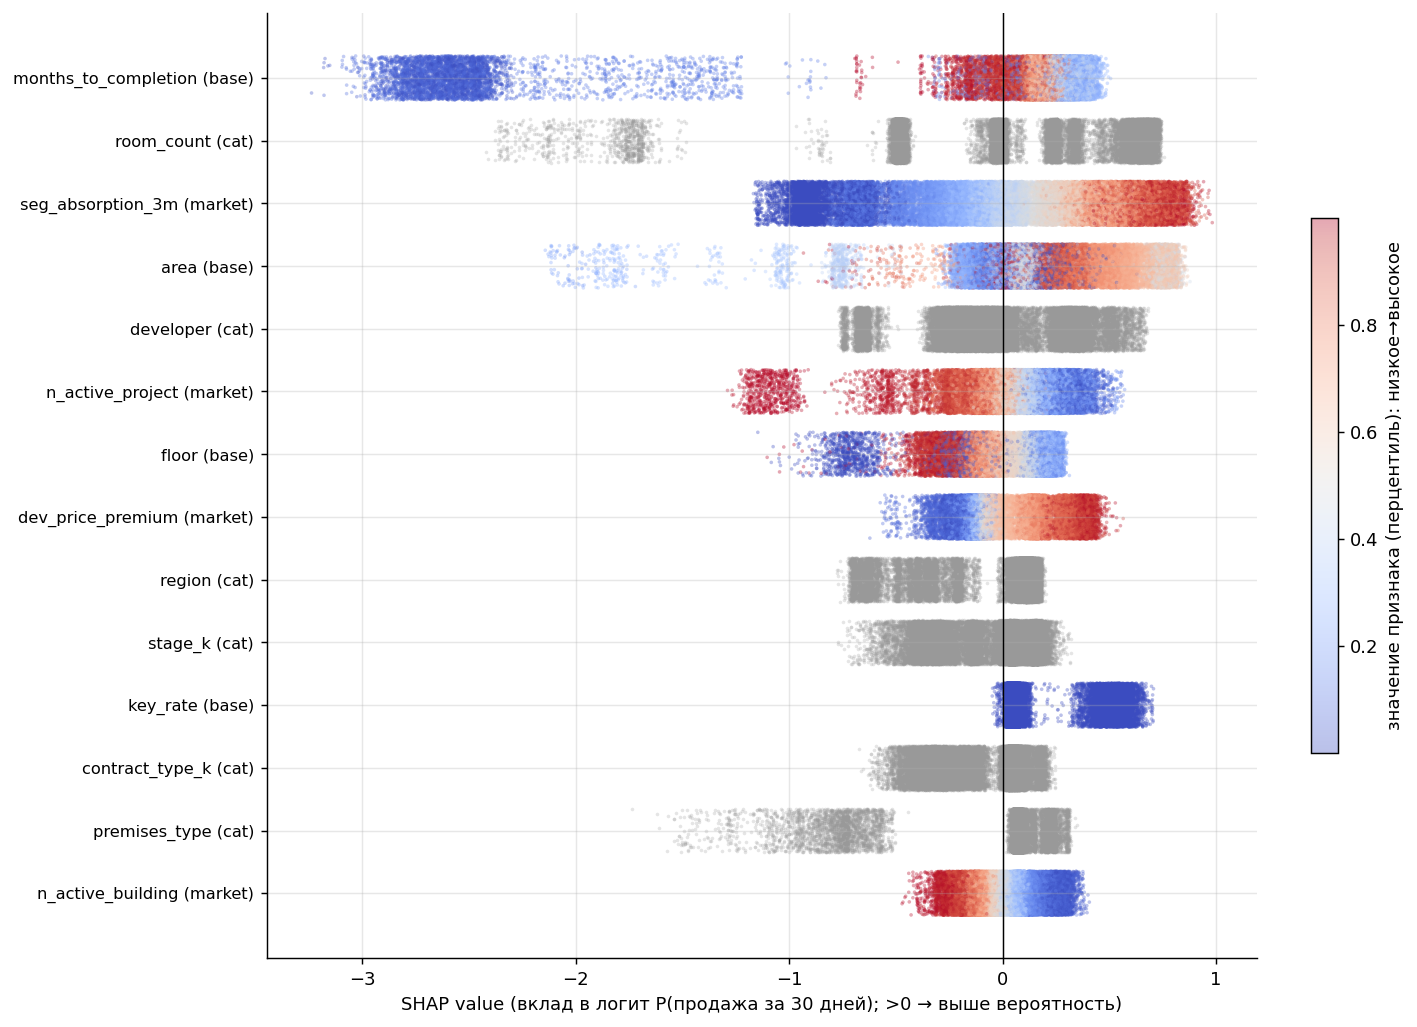

In [11]:
# Блок 5.2 — SHAP: направление и сила влияния признаков (native CatBoost, выборка теста)
samp = X_test.sample(n=min(40000, len(X_test)), random_state=42)
sv = model.get_feature_importance(Pool(samp, cat_features=CAT_FEATURES), type="ShapValues")
base_val, shap = sv[:, -1].mean(), sv[:, :-1]          # последний столбец — base value; остальное — вклад фич
mean_abs = pd.Series(np.abs(shap).mean(0), index=feats).sort_values(ascending=False)

print(f"SHAP base value (логит) = {base_val:.3f}\n")
print(f"{'признак':30s}{'группа':8s}{'mean|shap|':>11s}{'corr':>7s}  направление")
for f in mean_abs.head(20).index:
    j = feats.index(f); ma = mean_abs[f]
    if f in CAT_FEATURES:
        print(f"{f:30s}{_grp(f):8s}{ma:11.4f}{'--':>7s}  категориальный (знак не определён)")
    else:
        x = pd.to_numeric(samp[f], errors="coerce").to_numpy(); s = shap[:, j]
        ok = ~np.isnan(x)
        c = np.corrcoef(x[ok], s[ok])[0, 1] if ok.sum() > 10 and np.nanstd(x[ok]) > 0 else np.nan
        arrow = "↑ → выше P" if c > 0 else ("↑ → ниже P" if c < 0 else "≈0")
        print(f"{f:30s}{_grp(f):8s}{ma:11.4f}{c:7.2f}  {arrow}")

# beeswarm для топ-14 признаков: x — SHAP, цвет — величина признака (перцентиль)
topN = mean_abs.head(14).index[::-1]
fig, ax = plt.subplots(figsize=(11, 8)); rng = np.random.default_rng(42); sca = None
for yi, f in enumerate(topN):
    j = feats.index(f); s = shap[:, j]; jit = (rng.random(len(s)) - 0.5) * 0.7
    if f in CAT_FEATURES:
        ax.scatter(s, np.full(len(s), yi) + jit, s=4, c="0.6", alpha=0.25, linewidths=0)
    else:
        cvals = pd.Series(pd.to_numeric(samp[f], errors="coerce").to_numpy()).rank(pct=True).to_numpy()
        sca = ax.scatter(s, np.full(len(s), yi) + jit, s=4, c=cvals, cmap="coolwarm", alpha=0.35, linewidths=0)
ax.axvline(0, color="k", lw=0.8)
ax.set_yticks(range(len(topN))); ax.set_yticklabels([f"{f} ({_grp(f)})" for f in topN], fontsize=9)
ax.set_xlabel("SHAP value (вклад в логит P(продажа за 30 дней); >0 → выше вероятность)")
if sca is not None:
    cb = fig.colorbar(sca, ax=ax, fraction=0.025); cb.set_label("значение признака (перцентиль): низкое→высокое")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_shap_summary.png", bbox_inches="tight"); plt.show()